# Data_A -> less than 35 rows -> Eliminate all Nan Cols -> Operational Limits -> last 48 hours -> Avg Impu

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = None


# Folder containing the .psv files you want to process.
DATA_DIR = Path("/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Data_A")

# Column used to classify patients.
LABEL_COL = "SepsisLabel"

# Patient must have at least this many rows before the 48-hour formatting step.
MIN_ROWS = 36

# Final sequence length.
TIME_WINDOW = 48

# Features used for the all-NaN feature-column patient removal step.
FEATURES = ["HR", "O2Sat", "Temp", "SBP", "DBP", "Resp", "MAP"]

# Operating limits. Values outside these ranges are replaced with NaN.
LIMITS = {
    "HR":    (30, 220),
    "MAP":   (40, 160),
    "O2Sat": (70, 100),
    "Temp":  (32, 42),
    "SBP":   (40, 260),
    "DBP":   (20, 150),
    "Resp":  (4, 50),
}

# Columns excluded from average imputation.
AVG_IMPUTATION_IGNORE = {"SepsisLabel", "Unit1", "Unit2"}

# Set to True first if you want to preview counts without deleting/updating files.
DRY_RUN = False


# =========================
# Helper functions
# =========================

def get_psv_files(data_dir):
    """Return all .psv files in sorted order."""
    return sorted(Path(data_dir).glob("*.psv"))


def read_psv(fn):
    """Read one .psv file using the same NaN rules as your earlier scripts."""
    return pd.read_csv(fn, sep="|", na_values=["", "NaN", "nan"], keep_default_na=True)


def patient_status_from_df(df, label_col=LABEL_COL):
    """
    Classify one patient file.

    Septic:     patient has at least one SepsisLabel equal to 1
    Nonseptic:  patient has SepsisLabel values, but none equal to 1
    Unknown:    missing/empty SepsisLabel
    """
    if label_col not in df.columns or df.shape[0] == 0:
        return "Unknown"

    labels = pd.to_numeric(df[label_col], errors="coerce").dropna()

    if labels.empty:
        return "Unknown"
    elif (labels == 1).any():
        return "Septic"
    else:
        return "Nonseptic"


def cohort_counts(data_dir):
    """Count total, septic, nonseptic, unknown, and unreadable patients currently in DATA_DIR."""
    files = get_psv_files(data_dir)

    counts = {
        "Total Patients": len(files),
        "Septic": 0,
        "Nonseptic": 0,
        "Unknown Label": 0,
        "Unreadable Files": 0,
    }

    for fn in files:
        try:
            df = read_psv(fn)
            status = patient_status_from_df(df)
            if status == "Septic":
                counts["Septic"] += 1
            elif status == "Nonseptic":
                counts["Nonseptic"] += 1
            else:
                counts["Unknown Label"] += 1
        except Exception:
            counts["Unreadable Files"] += 1
            counts["Unknown Label"] += 1

    return counts


def add_summary_row(summary_rows, process_name, before_counts, after_counts,
                    removed=0, updated=0, skipped=0, notes=""):
    """Store one row for the summary table."""
    summary_rows.append({
        "Process": process_name,
        "Patients Before": before_counts.get("Total Patients", np.nan),
        "Patients After": after_counts.get("Total Patients", np.nan),
        "Removed": removed,
        "Updated": updated,
        "Skipped": skipped,
        "Septic After": after_counts.get("Septic", np.nan),
        "Nonseptic After": after_counts.get("Nonseptic", np.nan),
        "Unknown Label After": after_counts.get("Unknown Label", np.nan),
        "Unreadable Files After": after_counts.get("Unreadable Files", np.nan),
        "Notes": notes,
    })


def show_table(df, title=None):
    """Display nicely in Jupyter; otherwise print."""
    if title:
        print(f"\n{title}")
        print("-" * len(title))
    if display is not None:
        display(df)
    else:
        print(df.to_string(index=False))


# =========================
# Process 1: Drop patients with fewer than MIN_ROWS rows
# =========================

def drop_patients_with_less_than_min_rows(data_dir, min_rows=MIN_ROWS):
    """
    Delete a patient file if it has fewer than min_rows rows.
    This follows your drop_less_36_rows.py logic.
    """
    files = get_psv_files(data_dir)

    deleted = 0
    unreadable = 0

    for fn in files:
        try:
            df = read_psv(fn)
        except Exception:
            unreadable += 1
            continue

        if len(df) < min_rows:
            if not DRY_RUN:
                os.remove(fn)
            deleted += 1

    return {
        "removed": deleted,
        "updated": 0,
        "skipped": unreadable,
        "unreadable": unreadable,
    }


# =========================
# Process 2: Drop patients with any all-NaN required feature column
# =========================

def drop_patients_with_all_nan_feature(data_dir, features=FEATURES):
    """
    Delete a patient file if any required feature is completely NaN for that patient.

    Example: if HR is all NaN for patient_001.psv, then patient_001.psv is removed.
    This follows the logic from your drop_all_nan_cols.py file.
    """
    files = get_psv_files(data_dir)

    deleted = 0
    skipped_missing_features = 0
    unreadable = 0

    for fn in files:
        try:
            df = read_psv(fn)
        except Exception:
            unreadable += 1
            continue

        if any(c not in df.columns for c in features):
            skipped_missing_features += 1
            continue

        nan_cols = df[features].isna().all(axis=0).sum()

        if nan_cols >= 1:
            if not DRY_RUN:
                os.remove(fn)
            deleted += 1

    return {
        "removed": deleted,
        "updated": 0,
        "skipped": skipped_missing_features + unreadable,
        "skipped_missing_features": skipped_missing_features,
        "unreadable": unreadable,
    }


# =========================
# Process 3: Operating limits
# =========================

def apply_operating_limits(data_dir, limits=LIMITS):
    """
    Replace out-of-range values with NaN.
    This does not remove patients.
    """
    files = get_psv_files(data_dir)

    n_updated = 0
    n_bad = 0
    n_missing_limit_cols = 0
    total_replaced = {col: 0 for col in limits}

    for fn in files:
        try:
            df = read_psv(fn)
        except Exception:
            n_bad += 1
            continue

        changed_any = False
        missing_any = False

        for col, (lo, hi) in limits.items():
            if col not in df.columns:
                missing_any = True
                continue

            x = pd.to_numeric(df[col], errors="coerce")
            out = (x < lo) | (x > hi)

            if out.any():
                c = int(out.sum())
                total_replaced[col] += c
                df.loc[out, col] = np.nan
                changed_any = True

        if missing_any:
            n_missing_limit_cols += 1

        if changed_any:
            if not DRY_RUN:
                df.to_csv(fn, sep="|", index=False)
            n_updated += 1

    return {
        "removed": 0,
        "updated": n_updated,
        "skipped": n_bad,
        "missing_limit_cols": n_missing_limit_cols,
        "total_replaced": total_replaced,
    }


# =========================
# Process 4: Keep/pad to the last TIME_WINDOW hours
# =========================

def keep_or_pad_last_time_window(data_dir, time_window=TIME_WINDOW, label_col=LABEL_COL):
    """
    Make every patient file have exactly time_window rows.

    If rows > time_window:
        keep the last time_window rows.
    If rows < time_window:
        add NaN rows at the beginning and fill the padded SepsisLabel using the last observed label.
    If rows == time_window:
        reset the index and save.
    """
    files = get_psv_files(data_dir)

    updated = 0
    skipped = 0
    trimmed = 0
    padded = 0
    unchanged_length = 0

    for fn in files:
        try:
            df = read_psv(fn)
        except Exception:
            skipped += 1
            continue

        if df is None or df.shape[0] == 0 or label_col not in df.columns:
            skipped += 1
            continue

        n = len(df)

        if n > time_window:
            df_out = df.tail(time_window).reset_index(drop=True)
            trimmed += 1
        elif n < time_window:
            pad_n = time_window - n
            last_label = df[label_col].iloc[-1]

            pad = pd.DataFrame(np.nan, index=range(pad_n), columns=df.columns)
            pad[label_col] = last_label

            df_out = pd.concat([pad, df.reset_index(drop=True)], ignore_index=True)
            padded += 1
        else:
            df_out = df.reset_index(drop=True)
            unchanged_length += 1

        if not DRY_RUN:
            df_out.to_csv(fn, sep="|", index=False)
        updated += 1

    return {
        "removed": 0,
        "updated": updated,
        "skipped": skipped,
        "trimmed": trimmed,
        "padded": padded,
        "unchanged_length": unchanged_length,
    }


# =========================
# Process 5: Average imputation
# =========================

def apply_avg_imputation(data_dir, ignore=AVG_IMPUTATION_IGNORE):
    """
    For every numeric feature column (excluding `ignore`), fill a single isolated
    NaN that sits between two observed values with their average.

    Concretely: if arr[i] and arr[j] are both non-NaN and j - i == 2, then
    arr[i+1] = (arr[i] + arr[j]) / 2.0.

    Only gaps of exactly one missing row are filled; longer runs are left as NaN.
    Files are overwritten in place (skipped in DRY_RUN mode).
    """
    files = get_psv_files(data_dir)

    n_updated = 0
    n_skipped = 0
    total_filled = 0

    for fn in files:
        try:
            df = read_psv(fn)
        except Exception:
            n_skipped += 1
            continue

        # Select numeric columns that are not in the ignore set.
        num_cols = [
            c for c in df.columns
            if c not in ignore and np.issubdtype(df[c].dtype, np.number)
        ]

        filled_this_file = 0

        for col in num_cols:
            arr = df[col].to_numpy(dtype=float)
            observed_idx = np.where(~np.isnan(arr))[0]

            for i, j in zip(observed_idx, observed_idx[1:]):
                if j - i == 2:                          # exactly one gap
                    arr[i + 1] = (arr[i] + arr[j]) / 2.0
                    filled_this_file += 1

            df[col] = arr

        total_filled += filled_this_file

        if filled_this_file > 0:
            if not DRY_RUN:
                df.to_csv(fn, sep="|", index=False)
            n_updated += 1

    return {
        "removed": 0,
        "updated": n_updated,
        "skipped": n_skipped,
        "total_filled": total_filled,
    }


# =========================
# Run full pipeline in the requested order
# =========================

def run_pipeline(data_dir=DATA_DIR):
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(f"DATA_DIR does not exist: {data_dir}")

    if len(get_psv_files(data_dir)) == 0:
        raise FileNotFoundError(f"No .psv files found in: {data_dir}")

    summary_rows = []

    # Process 0: FullDataset baseline counts
    full_counts = cohort_counts(data_dir)
    summary_rows.append({
        "Process": "0. FullDataset",
        "Patients Before": np.nan,
        "Patients After": full_counts["Total Patients"],
        "Removed": 0,
        "Updated": 0,
        "Skipped": 0,
        "Septic After": full_counts["Septic"],
        "Nonseptic After": full_counts["Nonseptic"],
        "Unknown Label After": full_counts["Unknown Label"],
        "Unreadable Files After": full_counts["Unreadable Files"],
        "Notes": "Original dataset before preprocessing",
    })

    # Process 1: Remove patients with less than 36 rows
    before = cohort_counts(data_dir)
    info_rows = drop_patients_with_less_than_min_rows(data_dir)
    after = cohort_counts(data_dir)
    add_summary_row(
        summary_rows,
        f"1. Remove patients with < {MIN_ROWS} rows",
        before,
        after,
        removed=info_rows["removed"],
        updated=info_rows["updated"],
        skipped=info_rows["skipped"],
        notes=f"Unreadable: {info_rows['unreadable']}",
    )

    # Process 2: Eliminate patients with all-NaN values in the feature list
    before = cohort_counts(data_dir)
    info_nan = drop_patients_with_all_nan_feature(data_dir)
    after = cohort_counts(data_dir)
    add_summary_row(
        summary_rows,
        "2. Eliminate patients with any all-NaN feature column",
        before,
        after,
        removed=info_nan["removed"],
        updated=info_nan["updated"],
        skipped=info_nan["skipped"],
        notes=f"Skipped missing required features: {info_nan['skipped_missing_features']}; unreadable: {info_nan['unreadable']}",
    )

    # Process 3: Replace values outside operational limits with NaN
    before = cohort_counts(data_dir)
    info_limits = apply_operating_limits(data_dir)
    after = cohort_counts(data_dir)
    replaced_short = ", ".join([f"{k}={v}" for k, v in info_limits["total_replaced"].items()])
    add_summary_row(
        summary_rows,
        "3. Replace values outside operational limits with NaN",
        before,
        after,
        removed=info_limits["removed"],
        updated=info_limits["updated"],
        skipped=info_limits["skipped"],
        notes=f"Values replaced: {replaced_short}. Files missing limit columns: {info_limits['missing_limit_cols']}",
    )

    # Process 4: Get patients' last 48 hours
    before = cohort_counts(data_dir)
    info_48 = keep_or_pad_last_time_window(data_dir)
    after = cohort_counts(data_dir)
    add_summary_row(
        summary_rows,
        f"4. Get patients' last {TIME_WINDOW} hours",
        before,
        after,
        removed=info_48["removed"],
        updated=info_48["updated"],
        skipped=info_48["skipped"],
        notes=f"Trimmed: {info_48['trimmed']}; padded: {info_48['padded']}; already {TIME_WINDOW} rows: {info_48['unchanged_length']}",
    )

    # Process 5: Average imputation
    before = cohort_counts(data_dir)
    info_avg = apply_avg_imputation(data_dir)
    after = cohort_counts(data_dir)
    add_summary_row(
        summary_rows,
        "5. Average imputation",
        before,
        after,
        removed=info_avg["removed"],
        updated=info_avg["updated"],
        skipped=info_avg["skipped"],
        notes=f"Single-gap NaNs filled: {info_avg['total_filled']}",
    )

    summary_df = pd.DataFrame(summary_rows)

    replacements_df = pd.DataFrame({
        "Feature": list(info_limits["total_replaced"].keys()),
        "Values Replaced With NaN": list(info_limits["total_replaced"].values()),
    })

    show_table(summary_df, "Patient count after each preprocessing process")
    show_table(replacements_df, "Operating-limit replacements by feature")

    return summary_df, replacements_df


# Run the pipeline.
summary_df, replacements_df = run_pipeline(DATA_DIR)


Patient count after each preprocessing process
----------------------------------------------


,Process,Patients Before,Patients After,Removed,Updated,Skipped,Septic After,Nonseptic After,Unknown Label After,Unreadable Files After,Notes
0,0. FullDataset,NaN,20336,0,0,0,1790,18546,0,0,Original dataset before preprocessing
1,1. Remove patients with < 36 rows,20336.0,12232,8104,0,0,917,11315,0,0,Unreadable: 0
2,2. Eliminate patients with any all-NaN feature...,12232.0,8257,3975,0,0,761,7496,0,0,Skipped missing required features: 0; unreadab...
3,3. Replace values outside operational limits w...,8257.0,8257,0,947,0,761,7496,0,0,"Values replaced: HR=28, MAP=834, O2Sat=283, Te..."
4,4. Get patients' last 48 hours,8257.0,8257,0,8257,0,761,7496,0,0,Trimmed: 3182; padded: 4730; already 48 rows: 345
5,5. Average imputation,8257.0,8257,0,8023,0,761,7496,0,0,Single-gap NaNs filled: 118995



Operating-limit replacements by feature
---------------------------------------


,Feature,Values Replaced With NaN
0,HR,28
1,MAP,834
2,O2Sat,283
3,Temp,39
4,SBP,16
5,DBP,74
6,Resp,232


# Dataset A

## BRITS on Dataset A 


### Basic BRITS

Total Patients: 8257
- Septic: 761
- Nonseptic: 7496

Using device: cpu
Total patients:      8257
Training patients:   5779
Validation patients: 2478


,stage,patients,septic,nonseptic,missing_feature_values
0,Before BRITS,8257,761,7496,624555


,feature,mean,std
0,HR,85.540970,16.705399
1,O2Sat,97.343948,2.559083
2,Temp,37.119366,0.762526
3,SBP,121.312759,21.846336
4,DBP,60.145828,12.675991
5,Resp,18.653605,5.354108
6,MAP,79.013359,14.641771


Epoch 001 | train_loss=5.243551 | val_loss=4.401628 | train_mae=0.638101 | val_mae=0.475868 | train_rmse=0.835545 | val_rmse=0.656435
Epoch 002 | train_loss=4.168391 | val_loss=3.986965 | train_mae=0.432955 | val_mae=0.409003 | train_rmse=0.608709 | val_rmse=0.582023
Epoch 003 | train_loss=3.898204 | val_loss=3.790714 | train_mae=0.398293 | val_mae=0.386165 | train_rmse=0.571019 | val_rmse=0.562778
Epoch 004 | train_loss=3.724762 | val_loss=3.648225 | train_mae=0.380518 | val_mae=0.374790 | train_rmse=0.550633 | val_rmse=0.548625
Epoch 005 | train_loss=3.602007 | val_loss=3.546582 | train_mae=0.370630 | val_mae=0.363883 | train_rmse=0.540200 | val_rmse=0.535889
Epoch 006 | train_loss=3.510333 | val_loss=3.471959 | train_mae=0.360936 | val_mae=0.359126 | train_rmse=0.533403 | val_rmse=0.532644
Epoch 007 | train_loss=3.442227 | val_loss=3.412661 | train_mae=0.357494 | val_mae=0.355610 | train_rmse=0.527571 | val_rmse=0.528228
Epoch 008 | train_loss=3.391575 | val_loss=3.367198 | train_ma

,epoch,train_loss,val_loss,train_mae,val_mae,train_rmse,val_rmse
0,1,5.243551,4.401628,0.638101,0.475868,0.835545,0.656435
1,2,4.168391,3.986965,0.432955,0.409003,0.608709,0.582023
2,3,3.898204,3.790714,0.398293,0.386165,0.571019,0.562778
3,4,3.724762,3.648225,0.380518,0.374790,0.550633,0.548625
4,5,3.602007,3.546582,0.370630,0.363883,0.540200,0.535889
5,6,3.510333,3.471959,0.360936,0.359126,0.533403,0.532644
6,7,3.442227,3.412661,0.357494,0.355610,0.527571,0.528228
7,8,3.391575,3.367198,0.356027,0.353607,0.532453,0.531915
8,9,3.342452,3.328237,0.349026,0.351759,0.517313,0.524686
9,10,3.306134,3.295703,0.347650,0.349250,0.518462,0.525796


,metric,best_value,epoch
0,Train Loss,3.085196,50
1,Validation Loss,3.093470,48
2,Train MAE,0.333092,23
3,Validation MAE,0.333482,24
4,Train RMSE,0.510697,14
5,Validation RMSE,0.507312,15


Best model by validation MAE happened at epoch 24.
Using best validation MAE model from epoch 24 for original-unit metrics.


,feature,train_mae_original_units,val_mae_original_units,train_rmse_original_units,val_rmse_original_units,val_hidden_points_used
0,HR,4.258784,4.154621,6.400703,6.341486,10544
1,O2Sat,1.036419,1.028816,1.671613,1.659434,10233
2,Temp,0.314447,0.312496,0.444834,0.446324,4462
3,SBP,7.238243,7.202614,10.043177,9.823951,9657
4,DBP,3.447359,3.514885,5.776134,5.884077,8520
5,Resp,2.445808,2.406294,3.428841,3.358597,10366
6,MAP,3.854459,3.754320,6.224416,6.016941,10425



Original-unit MAE/RMSE are computed only on the observed values that were artificially hidden.


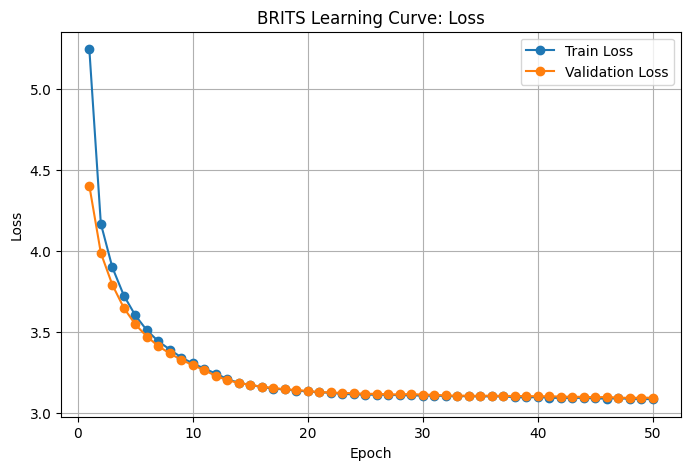

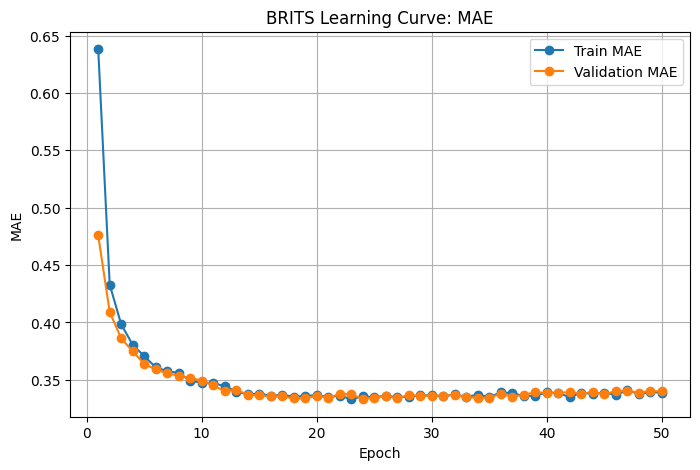

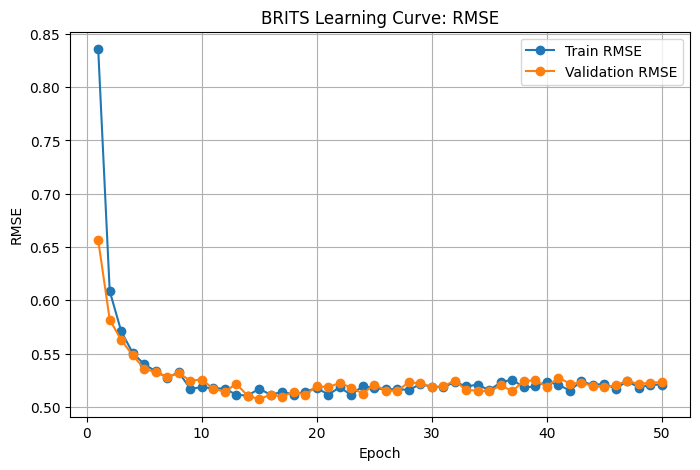

Using best in-memory model from epoch 24 for imputation.

Original .psv files have been overwritten with BRITS-imputed values.


,stage,patients,septic,nonseptic,missing_feature_values
0,Before BRITS,8257,761,7496,624555
1,After BRITS,8257,761,7496,0



Done.
Files overwritten in:
/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Data_A


In [8]:

import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. BASIC SETTINGS
# ============================================================

DATASET_DIR = "/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Data_A"

FEAT_COLS = ["HR", "O2Sat", "Temp", "SBP", "DBP", "Resp", "MAP"]

T = 48
EPOCHS = 50
BATCH_SIZE = 64
HIDDEN_SIZE = 64
HOLDOUT_FRAC = 0.10
TRAIN_FRAC = 0.70
SEED = 123

OVERWRITE_FILES = True
USE_BEST_MODEL_FOR_IMPUTATION = True


# ============================================================
# 2. SEED AND DEVICE
# ============================================================

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 3. DATASET FUNCTIONS
# ============================================================

def list_psv_files(dataset_dir):
    files = sorted(Path(dataset_dir).glob("*.psv"))

    if len(files) == 0:
        raise FileNotFoundError(f"No .psv files found in: {dataset_dir}")

    return [str(f) for f in files]


def split_files(files, train_frac=0.80, seed=123):
    rng = np.random.default_rng(seed)

    files = np.array(files)
    idx = rng.permutation(len(files))

    n_train = int(len(files) * train_frac)

    train_files = files[idx[:n_train]].tolist()
    val_files = files[idx[n_train:]].tolist()

    return train_files, val_files


def read_patient_file(path):
    df = pd.read_csv(path, sep="|")

    for col in FEAT_COLS:
        if col not in df.columns:
            raise ValueError(f"{Path(path).name} is missing feature column: {col}")

        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def get_patient_array(df, path_name="patient"):
    """
    Assumes every patient is already padded to exactly T rows.
    """
    if len(df) != T:
        raise ValueError(
            f"{path_name} has {len(df)} rows, but expected {T}. "
            "Since your dataset is already padded, every file should have exactly 48 rows."
        )

    x = df[FEAT_COLS].to_numpy(dtype=np.float32)

    return x


def get_patient_label(df):
    if "SepsisLabel" not in df.columns:
        return 0

    return int(pd.to_numeric(df["SepsisLabel"], errors="coerce").fillna(0).max())


def compute_train_mean_std(train_files):
    all_values = []

    for path in train_files:
        df = read_patient_file(path)
        x = get_patient_array(df, path_name=Path(path).name)
        all_values.append(x)

    all_values = np.vstack(all_values)

    mean = np.nanmean(all_values, axis=0)
    std = np.nanstd(all_values, axis=0)

    mean = np.where(np.isnan(mean), 0.0, mean)
    std = np.where((np.isnan(std)) | (std < 1e-8), 1.0, std)

    return mean.astype(np.float32), std.astype(np.float32)


class PatientDataset(Dataset):
    def __init__(self, files, mean, std):
        self.files = files
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        df = read_patient_file(path)

        x = get_patient_array(df, path_name=Path(path).name)

        # Normalize but keep NaNs as NaNs.
        x = (x - self.mean) / self.std

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "path": path,
            "label": get_patient_label(df),
        }


# ============================================================
# 4. BRITS MODEL FUNCTIONS
# ============================================================

def build_mask_from_nan(x):
    """
    1 = observed, 0 = missing
    """
    return (~torch.isnan(x)).float()


def fill_nan_with_zero(x):
    return torch.nan_to_num(x, nan=0.0)


def reverse_time(x):
    return torch.flip(x, dims=[1])


def build_deltas(mask):
    """
    mask: [B, T, F]
    delta[:, t, f] = number of time steps since feature f was last observed
    """
    delta = torch.zeros_like(mask)

    for t in range(1, mask.shape[1]):
        delta[:, t, :] = 1.0 + (1.0 - mask[:, t - 1, :]) * delta[:, t - 1, :]

    return delta


def masked_mae(pred, target, mask):
    denom = mask.sum().clamp_min(1.0)
    return (torch.abs(pred - target) * mask).sum() / denom


def masked_rmse(pred, target, mask):
    denom = mask.sum().clamp_min(1.0)
    mse = (((pred - target) ** 2) * mask).sum() / denom
    return torch.sqrt(mse + 1e-12)


def denormalize_tensor(x_norm, mean, std):
    """
    Converts normalized values back to original clinical units.

    Example:
        HR normalized -> HR beats per minute
        Temp normalized -> Temp original units
        MAP normalized -> MAP mmHg
    """
    mean_t = torch.tensor(mean, dtype=x_norm.dtype, device=x_norm.device).view(1, 1, -1)
    std_t = torch.tensor(std, dtype=x_norm.dtype, device=x_norm.device).view(1, 1, -1)

    return x_norm * std_t + mean_t


def masked_mae_per_feature(pred, target, mask):
    """
    Computes MAE separately for each feature.
    Returns a tensor with shape [number_of_features].
    """
    denom = mask.sum(dim=(0, 1)).clamp_min(1.0)
    mae = (torch.abs(pred - target) * mask).sum(dim=(0, 1)) / denom

    return mae


def masked_rmse_per_feature(pred, target, mask):
    """
    Computes RMSE separately for each feature.
    Returns a tensor with shape [number_of_features].
    """
    denom = mask.sum(dim=(0, 1)).clamp_min(1.0)
    mse = (((pred - target) ** 2) * mask).sum(dim=(0, 1)) / denom
    rmse = torch.sqrt(mse + 1e-12)

    return rmse


class FeatureRegression(nn.Module):
    """
    Predict each feature from the other features at the same time step.
    The diagonal is zero, so a feature cannot directly copy itself.
    """
    def __init__(self, n_features):
        super().__init__()

        self.W = nn.Parameter(torch.empty(n_features, n_features))
        self.b = nn.Parameter(torch.zeros(n_features))

        self.register_buffer("diag_mask", 1.0 - torch.eye(n_features))

        nn.init.xavier_uniform_(self.W)

    def forward(self, x):
        W = self.W * self.diag_mask
        return F.linear(x, W, self.b)


class TemporalDecay(nn.Module):
    """
    gamma = exp(-relu(W delta + b))
    """
    def __init__(self, input_size, output_size):
        super().__init__()

        self.linear = nn.Linear(input_size, output_size)

    def forward(self, delta):
        return torch.exp(-F.relu(self.linear(delta)))


class RITSBlock(nn.Module):
    def __init__(self, n_features, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.temp_decay_h = TemporalDecay(n_features, hidden_size)
        self.temp_decay_x = TemporalDecay(n_features, n_features)

        self.hist_reg = nn.Linear(hidden_size, n_features)
        self.feat_reg = FeatureRegression(n_features)

        self.combine = nn.Linear(2 * n_features, n_features)
        self.rnn_cell = nn.GRUCell(2 * n_features, hidden_size)

    def forward(self, x, m, d):
        B, T_seq, F_dim = x.shape

        h = torch.zeros(B, self.hidden_size, device=x.device)

        imputations = []
        total_loss = x.new_tensor(0.0)

        for t in range(T_seq):
            x_t = x[:, t, :]
            m_t = m[:, t, :]
            d_t = d[:, t, :]

            gamma_h = self.temp_decay_h(d_t)
            gamma_x = self.temp_decay_x(d_t)

            h = h * gamma_h

            # History-based estimate
            x_hist = self.hist_reg(h)
            total_loss = total_loss + masked_mae(x_hist, x_t, m_t)

            # Fill missing entries with history estimate
            x_c = m_t * x_t + (1.0 - m_t) * x_hist

            # Feature-based estimate
            z_feat = self.feat_reg(x_c)
            total_loss = total_loss + masked_mae(z_feat, x_t, m_t)

            # Combine history and feature estimates
            alpha = torch.sigmoid(self.combine(torch.cat([gamma_x, m_t], dim=1)))
            c_hat = alpha * z_feat + (1.0 - alpha) * x_hist
            total_loss = total_loss + masked_mae(c_hat, x_t, m_t)

            # Final imputed value for this time step
            x_imp = m_t * x_t + (1.0 - m_t) * c_hat
            imputations.append(x_imp.unsqueeze(1))

            # RNN update
            rnn_input = torch.cat([x_imp, m_t], dim=1)
            h = self.rnn_cell(rnn_input, h)

        imputations = torch.cat(imputations, dim=1)
        total_loss = total_loss / T_seq

        return {
            "imputed": imputations,
            "loss": total_loss,
        }


class BRITSImputer(nn.Module):
    def __init__(self, n_features, hidden_size):
        super().__init__()

        self.rits_f = RITSBlock(n_features, hidden_size)
        self.rits_b = RITSBlock(n_features, hidden_size)

    def forward(self, x):
        """
        x: [B, T, F] with NaNs marking missing values
        """
        m = build_mask_from_nan(x)
        x_filled = fill_nan_with_zero(x)
        d = build_deltas(m)

        # Forward RITS
        out_f = self.rits_f(x_filled, m, d)

        # Backward RITS
        x_rev = reverse_time(x_filled)
        m_rev = reverse_time(m)
        d_rev = build_deltas(m_rev)

        out_b_rev = self.rits_b(x_rev, m_rev, d_rev)

        imputed_f = out_f["imputed"]
        imputed_b = reverse_time(out_b_rev["imputed"])

        # Forward/backward consistency
        consistency_loss = torch.mean(torch.abs(imputed_f - imputed_b))

        # Average forward and backward imputations
        imputed_avg = 0.5 * (imputed_f + imputed_b)

        # Keep observed values unchanged
        imputed_final = m * x_filled + (1.0 - m) * imputed_avg

        total_loss = out_f["loss"] + out_b_rev["loss"] + consistency_loss

        return {
            "imputed": imputed_final,
            "loss": total_loss,
            "consistency_loss": consistency_loss,
            "mask": m,
        }


# ============================================================
# 5. TRAINING AND EVALUATION FUNCTIONS
# ============================================================

def make_artificial_mask(x, holdout_frac=0.10):
    """
    Hide a fraction of observed values.
    These hidden values are used to measure reconstruction MAE/RMSE.
    """
    obs_mask = build_mask_from_nan(x)

    random_values = torch.rand_like(obs_mask)
    target_mask = ((random_values < holdout_frac).float() * obs_mask).float()

    x_hidden = x.clone()
    x_hidden[target_mask.bool()] = float("nan")

    return x_hidden, target_mask


def training_loss(model, x):
    """
    One training batch.
    Returns total loss, MAE, and RMSE.
    """
    x_hidden, target_mask = make_artificial_mask(x, holdout_frac=HOLDOUT_FRAC)

    out = model(x_hidden)

    x_true = fill_nan_with_zero(x)

    recon_mae = masked_mae(out["imputed"], x_true, target_mask)
    recon_rmse = masked_rmse(out["imputed"], x_true, target_mask)

    total_loss = recon_mae + out["loss"]

    return total_loss, recon_mae, recon_rmse, out


@torch.no_grad()
def evaluate_model(model, loader, mean=None, std=None):
    """
    Computes loss, normalized MAE/RMSE, and optionally
    original-unit MAE/RMSE for each feature.

    Normalized MAE/RMSE:
        Uses z-score units.

    Original-unit MAE/RMSE:
        Converts model output back using:
            original = normalized * std + mean
    """
    model.eval()

    losses = []
    maes = []
    rmses = []

    # These are only used when mean and std are provided.
    feature_abs_sum = torch.zeros(len(FEAT_COLS), dtype=torch.float32)
    feature_sq_sum = torch.zeros(len(FEAT_COLS), dtype=torch.float32)
    feature_count = torch.zeros(len(FEAT_COLS), dtype=torch.float32)

    for batch in loader:
        x = batch["x"].to(device)

        x_hidden, target_mask = make_artificial_mask(x, holdout_frac=HOLDOUT_FRAC)

        out = model(x_hidden)

        x_true_norm = fill_nan_with_zero(x)

        # Metrics in normalized z-score units.
        recon_mae = masked_mae(out["imputed"], x_true_norm, target_mask)
        recon_rmse = masked_rmse(out["imputed"], x_true_norm, target_mask)

        total_loss = recon_mae + out["loss"]

        losses.append(total_loss.item())
        maes.append(recon_mae.item())
        rmses.append(recon_rmse.item())

        # Metrics in original units for each feature.
        if mean is not None and std is not None:
            pred_orig = denormalize_tensor(out["imputed"], mean, std)
            true_orig = denormalize_tensor(x_true_norm, mean, std)

            diff_orig = pred_orig - true_orig

            feature_abs_sum += (torch.abs(diff_orig) * target_mask).sum(dim=(0, 1)).cpu()
            feature_sq_sum += ((diff_orig ** 2) * target_mask).sum(dim=(0, 1)).cpu()
            feature_count += target_mask.sum(dim=(0, 1)).cpu()

    results = {
        "loss": float(np.mean(losses)),
        "mae": float(np.mean(maes)),
        "rmse": float(np.mean(rmses)),
    }

    if mean is not None and std is not None:
        feature_mae_original = feature_abs_sum / feature_count.clamp_min(1.0)
        feature_rmse_original = torch.sqrt(
            feature_sq_sum / feature_count.clamp_min(1.0) + 1e-12
        )

        results["feature_mae_original"] = feature_mae_original.numpy()
        results["feature_rmse_original"] = feature_rmse_original.numpy()
        results["feature_count"] = feature_count.numpy()

    return results


# ============================================================
# 6. LOAD DATA AND SHOW BEFORE SUMMARY
# ============================================================

all_files = list_psv_files(DATASET_DIR)
train_files, val_files = split_files(all_files, train_frac=TRAIN_FRAC, seed=SEED)

print(f"Total patients:      {len(all_files)}")
print(f"Training patients:   {len(train_files)}")
print(f"Validation patients: {len(val_files)}")

summary_before_rows = []

for path in all_files:
    df = read_patient_file(path)
    x = get_patient_array(df, path_name=Path(path).name)

    summary_before_rows.append({
        "file": Path(path).name,
        "rows": len(df),
        "septic": get_patient_label(df),
        "missing_before": int(df[FEAT_COLS].isna().sum().sum()),
    })

summary_before = pd.DataFrame(summary_before_rows)

before_table = pd.DataFrame([{
    "stage": "Before BRITS",
    "patients": len(summary_before),
    "septic": int((summary_before["septic"] == 1).sum()),
    "nonseptic": int((summary_before["septic"] == 0).sum()),
    "missing_feature_values": int(summary_before["missing_before"].sum()),
}])

display(before_table)


# ============================================================
# 7. NORMALIZATION STATS
# ============================================================

mean, std = compute_train_mean_std(train_files)

stats_table = pd.DataFrame({
    "feature": FEAT_COLS,
    "mean": mean,
    "std": std,
})

display(stats_table)


# ============================================================
# 8. DATALOADERS
# ============================================================

train_dataset = PatientDataset(train_files, mean, std)
val_dataset = PatientDataset(val_files, mean, std)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ============================================================
# 9. TRAIN BRITS
# ============================================================

model = BRITSImputer(
    n_features=len(FEAT_COLS),
    hidden_size=HIDDEN_SIZE,
).to(device)

# Basic Adam optimizer.
optimizer = torch.optim.Adam(
    model.parameters())

history = []

best_val_mae = float("inf")
best_state = None
best_epoch = None

for epoch in range(1, EPOCHS + 1):
    model.train()

    train_losses = []
    train_maes = []
    train_rmses = []

    for batch in train_loader:
        x = batch["x"].to(device)

        optimizer.zero_grad()

        loss, train_mae, train_rmse, out = training_loss(model, x)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_maes.append(train_mae.item())
        train_rmses.append(train_rmse.item())

    val_metrics = evaluate_model(model, val_loader)

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_loss": val_metrics["loss"],
        "train_mae": float(np.mean(train_maes)),
        "val_mae": val_metrics["mae"],
        "train_rmse": float(np.mean(train_rmses)),
        "val_rmse": val_metrics["rmse"],
    }

    history.append(row)

    if row["val_mae"] < best_val_mae:
        best_val_mae = row["val_mae"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={row['train_loss']:.6f} | "
        f"val_loss={row['val_loss']:.6f} | "
        f"train_mae={row['train_mae']:.6f} | "
        f"val_mae={row['val_mae']:.6f} | "
        f"train_rmse={row['train_rmse']:.6f} | "
        f"val_rmse={row['val_rmse']:.6f}"
    )

history_df = pd.DataFrame(history)

display(history_df)


# ============================================================
# 10. BEST VALUES AND CORRESPONDING EPOCHS
# ============================================================

best_values = pd.DataFrame([
    {
        "metric": "Train Loss",
        "best_value": history_df.loc[history_df["train_loss"].idxmin(), "train_loss"],
        "epoch": int(history_df.loc[history_df["train_loss"].idxmin(), "epoch"]),
    },
    {
        "metric": "Validation Loss",
        "best_value": history_df.loc[history_df["val_loss"].idxmin(), "val_loss"],
        "epoch": int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"]),
    },
    {
        "metric": "Train MAE",
        "best_value": history_df.loc[history_df["train_mae"].idxmin(), "train_mae"],
        "epoch": int(history_df.loc[history_df["train_mae"].idxmin(), "epoch"]),
    },
    {
        "metric": "Validation MAE",
        "best_value": history_df.loc[history_df["val_mae"].idxmin(), "val_mae"],
        "epoch": int(history_df.loc[history_df["val_mae"].idxmin(), "epoch"]),
    },
    {
        "metric": "Train RMSE",
        "best_value": history_df.loc[history_df["train_rmse"].idxmin(), "train_rmse"],
        "epoch": int(history_df.loc[history_df["train_rmse"].idxmin(), "epoch"]),
    },
    {
        "metric": "Validation RMSE",
        "best_value": history_df.loc[history_df["val_rmse"].idxmin(), "val_rmse"],
        "epoch": int(history_df.loc[history_df["val_rmse"].idxmin(), "epoch"]),
    },
])

display(best_values)

print(f"Best model by validation MAE happened at epoch {best_epoch}.")


# ============================================================
# 11. ORIGINAL-UNIT MAE/RMSE BY FEATURE
# ============================================================

# The training loop above still reports normalized MAE/RMSE.
# This section reloads the best model and reports MAE/RMSE in real units
# for HR, O2Sat, Temp, SBP, DBP, Resp, and MAP.

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Using best validation MAE model from epoch {best_epoch} for original-unit metrics.")

model.eval()

train_original_metrics = evaluate_model(model, train_loader, mean, std)
val_original_metrics = evaluate_model(model, val_loader, mean, std)

original_units_table = pd.DataFrame({
    "feature": FEAT_COLS,
    "train_mae_original_units": train_original_metrics["feature_mae_original"],
    "val_mae_original_units": val_original_metrics["feature_mae_original"],
    "train_rmse_original_units": train_original_metrics["feature_rmse_original"],
    "val_rmse_original_units": val_original_metrics["feature_rmse_original"],
    "val_hidden_points_used": val_original_metrics["feature_count"].astype(int),
})

display(original_units_table)

print("\nOriginal-unit MAE/RMSE are computed only on the observed values that were artificially hidden.")


# ============================================================
# 12. LEARNING CURVES
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BRITS Learning Curve: Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_mae"], marker="o", label="Train MAE")
plt.plot(history_df["epoch"], history_df["val_mae"], marker="o", label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("BRITS Learning Curve: MAE")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(history_df["epoch"], history_df["val_rmse"], marker="o", label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("BRITS Learning Curve: RMSE")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 13. OVERWRITE ORIGINAL FILES WITH BRITS IMPUTED VALUES
# ============================================================

@torch.no_grad()
def impute_one_file(model, path, mean, std):
    df = read_patient_file(path)

    x = get_patient_array(df, path_name=Path(path).name)
    missing_mask_original = df[FEAT_COLS].isna()

    x_norm = (x - mean) / std

    x_tensor = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(device)

    out = model(x_tensor)

    imputed_norm = out["imputed"].squeeze(0).cpu().numpy()
    imputed = imputed_norm * std + mean

    if np.isnan(imputed).any():
        raise ValueError(f"BRITS produced NaN imputations for {Path(path).name}")

    df_out = df.copy()

    # Replace only the values that were originally missing.
    # Observed values are preserved exactly.
    for j, col in enumerate(FEAT_COLS):
        miss = missing_mask_original[col].to_numpy()
        df_out.loc[miss, col] = imputed[miss, j]

    return df_out


if USE_BEST_MODEL_FOR_IMPUTATION and best_state is not None:
    model.load_state_dict(best_state)
    print(f"Using best in-memory model from epoch {best_epoch} for imputation.")
else:
    print("Using final epoch model for imputation.")

if OVERWRITE_FILES:
    model.eval()

    for path in all_files:
        imputed_df = impute_one_file(model, path, mean, std)

        # This overwrites the original patient file.
        imputed_df.to_csv(path, sep="|", index=False)

    print("\nOriginal .psv files have been overwritten with BRITS-imputed values.")
else:
    print("\nOVERWRITE_FILES is False, so no files were changed.")


# ============================================================
# 14. AFTER SUMMARY
# ============================================================

summary_after_rows = []

for path in all_files:
    df = read_patient_file(path)
    x = get_patient_array(df, path_name=Path(path).name)

    summary_after_rows.append({
        "file": Path(path).name,
        "rows": len(df),
        "septic": get_patient_label(df),
        "missing_after": int(df[FEAT_COLS].isna().sum().sum()),
    })

summary_after = pd.DataFrame(summary_after_rows)

final_summary = pd.DataFrame([
    {
        "stage": "Before BRITS",
        "patients": len(summary_before),
        "septic": int((summary_before["septic"] == 1).sum()),
        "nonseptic": int((summary_before["septic"] == 0).sum()),
        "missing_feature_values": int(summary_before["missing_before"].sum()),
    },
    {
        "stage": "After BRITS",
        "patients": len(summary_after),
        "septic": int((summary_after["septic"] == 1).sum()),
        "nonseptic": int((summary_after["septic"] == 0).sum()),
        "missing_feature_values": int(summary_after["missing_after"].sum()),
    },
])

display(final_summary)

print("\nDone.")
print("Files overwritten in:")
print(DATASET_DIR)

### Tuning BRITS

Using device: cpu
Total patients:      8257
Training patients:   5779
Validation patients: 2478


,stage,patients,septic,nonseptic,missing_feature_values
0,Before BRITS,8257,761,7496,624555


,feature,mean,std
0,HR,85.540970,16.705399
1,O2Sat,97.343948,2.559083
2,Temp,37.119366,0.762526
3,SBP,121.312759,21.846336
4,DBP,60.145828,12.675991
5,Resp,18.653605,5.354108
6,MAP,79.013359,14.641771


Epoch 001 | train_loss=5.243551 | val_loss=4.401628 | train_mae=0.638101 | val_mae=0.475868 | train_rmse=0.835545 | val_rmse=0.656435
Epoch 002 | train_loss=4.168391 | val_loss=3.986965 | train_mae=0.432955 | val_mae=0.409003 | train_rmse=0.608709 | val_rmse=0.582023
Epoch 003 | train_loss=3.898204 | val_loss=3.790714 | train_mae=0.398293 | val_mae=0.386165 | train_rmse=0.571019 | val_rmse=0.562778
Epoch 004 | train_loss=3.724762 | val_loss=3.648225 | train_mae=0.380518 | val_mae=0.374790 | train_rmse=0.550633 | val_rmse=0.548625
Epoch 005 | train_loss=3.602007 | val_loss=3.546582 | train_mae=0.370630 | val_mae=0.363883 | train_rmse=0.540200 | val_rmse=0.535889
Epoch 006 | train_loss=3.510333 | val_loss=3.471959 | train_mae=0.360936 | val_mae=0.359126 | train_rmse=0.533403 | val_rmse=0.532644
Epoch 007 | train_loss=3.442227 | val_loss=3.412661 | train_mae=0.357494 | val_mae=0.355610 | train_rmse=0.527571 | val_rmse=0.528228
Epoch 008 | train_loss=3.391575 | val_loss=3.367198 | train_ma

,epoch,train_loss,val_loss,train_mae,val_mae,train_rmse,val_rmse
0,1,5.243551,4.401628,0.638101,0.475868,0.835545,0.656435
1,2,4.168391,3.986965,0.432955,0.409003,0.608709,0.582023
2,3,3.898204,3.790714,0.398293,0.386165,0.571019,0.562778
3,4,3.724762,3.648225,0.380518,0.374790,0.550633,0.548625
4,5,3.602007,3.546582,0.370630,0.363883,0.540200,0.535889
5,6,3.510333,3.471959,0.360936,0.359126,0.533403,0.532644
6,7,3.442227,3.412661,0.357494,0.355610,0.527571,0.528228
7,8,3.391575,3.367198,0.356027,0.353607,0.532453,0.531915
8,9,3.342452,3.328237,0.349026,0.351759,0.517313,0.524686
9,10,3.306134,3.295703,0.347650,0.349250,0.518462,0.525796


,metric,best_value,epoch
0,Train Loss,3.085196,50
1,Validation Loss,3.093470,48
2,Train MAE,0.333092,23
3,Validation MAE,0.333482,24
4,Train RMSE,0.510697,14
5,Validation RMSE,0.507312,15


Best model by validation MAE happened at epoch 24.
Using best validation MAE model from epoch 24 for original-unit metrics.


,feature,train_mae_original_units,val_mae_original_units,train_rmse_original_units,val_rmse_original_units,val_hidden_points_used
0,HR,4.258784,4.154621,6.400703,6.341486,10544
1,O2Sat,1.036419,1.028816,1.671613,1.659434,10233
2,Temp,0.314447,0.312496,0.444834,0.446324,4462
3,SBP,7.238243,7.202614,10.043177,9.823951,9657
4,DBP,3.447359,3.514885,5.776134,5.884077,8520
5,Resp,2.445808,2.406294,3.428841,3.358597,10366
6,MAP,3.854459,3.754320,6.224416,6.016941,10425



Original-unit MAE/RMSE are computed only on the observed values that were artificially hidden.


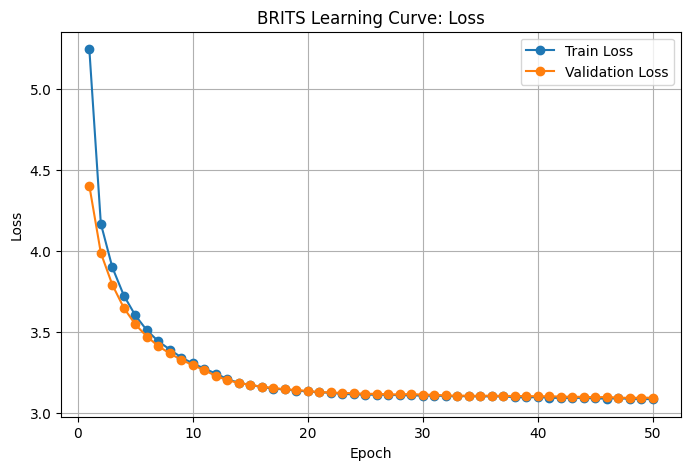

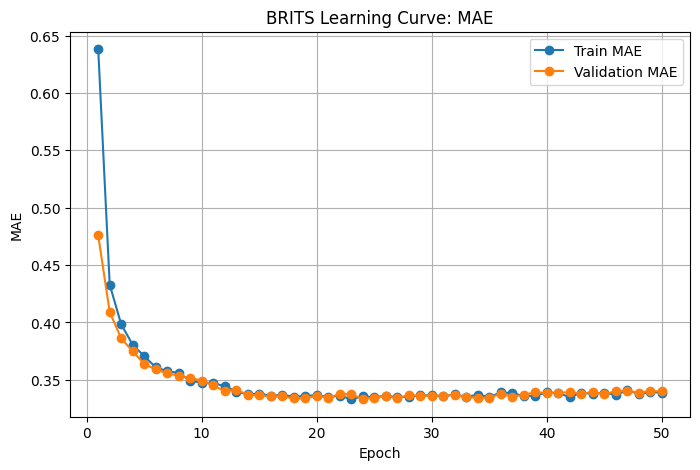

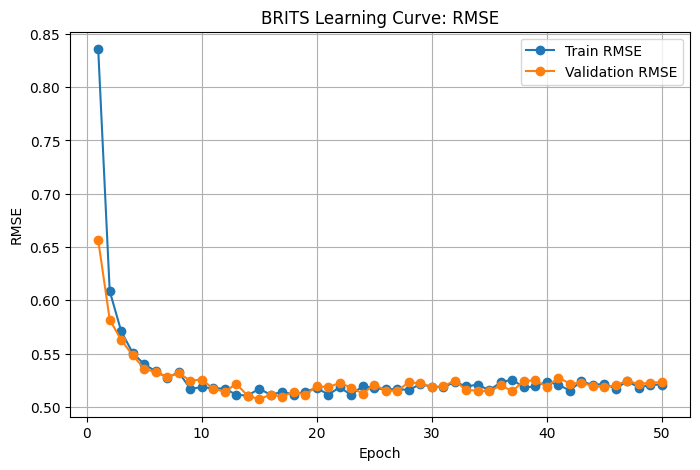

Using best in-memory model from epoch 24 for imputation.

OVERWRITE_FILES is False, so no files were changed.


,stage,patients,septic,nonseptic,missing_feature_values
0,Before BRITS,8257,761,7496,624555
1,After BRITS,8257,761,7496,624555



Done.
Files overwritten in:
/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Data_A


In [6]:

import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. BASIC SETTINGS
# ============================================================

DATASET_DIR = "/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Data_A"

FEAT_COLS = ["HR", "O2Sat", "Temp", "SBP", "DBP", "Resp", "MAP"]

T = 48
EPOCHS = 50
BATCH_SIZE = 64
HIDDEN_SIZE = 64
HOLDOUT_FRAC = 0.10
TRAIN_FRAC = 0.70
LEARNING_RATE = 1e-3
SEED = 123

OVERWRITE_FILES = False
USE_BEST_MODEL_FOR_IMPUTATION = True


# ============================================================
# 2. SEED AND DEVICE
# ============================================================

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 3. DATASET FUNCTIONS
# ============================================================

def list_psv_files(dataset_dir):
    files = sorted(Path(dataset_dir).glob("*.psv"))

    if len(files) == 0:
        raise FileNotFoundError(f"No .psv files found in: {dataset_dir}")

    return [str(f) for f in files]


def split_files(files, train_frac=0.80, seed=123):
    rng = np.random.default_rng(seed)

    files = np.array(files)
    idx = rng.permutation(len(files))

    n_train = int(len(files) * train_frac)

    train_files = files[idx[:n_train]].tolist()
    val_files = files[idx[n_train:]].tolist()

    return train_files, val_files


def read_patient_file(path):
    df = pd.read_csv(path, sep="|")

    for col in FEAT_COLS:
        if col not in df.columns:
            raise ValueError(f"{Path(path).name} is missing feature column: {col}")

        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def get_patient_array(df, path_name="patient"):
    """
    Assumes every patient is already padded to exactly T rows.
    """
    if len(df) != T:
        raise ValueError(
            f"{path_name} has {len(df)} rows, but expected {T}. "
            "Since your dataset is already padded, every file should have exactly 48 rows."
        )

    x = df[FEAT_COLS].to_numpy(dtype=np.float32)

    return x


def get_patient_label(df):
    if "SepsisLabel" not in df.columns:
        return 0

    return int(pd.to_numeric(df["SepsisLabel"], errors="coerce").fillna(0).max())


def compute_train_mean_std(train_files):
    all_values = []

    for path in train_files:
        df = read_patient_file(path)
        x = get_patient_array(df, path_name=Path(path).name)
        all_values.append(x)

    all_values = np.vstack(all_values)

    mean = np.nanmean(all_values, axis=0)
    std = np.nanstd(all_values, axis=0)

    mean = np.where(np.isnan(mean), 0.0, mean)
    std = np.where((np.isnan(std)) | (std < 1e-8), 1.0, std)

    return mean.astype(np.float32), std.astype(np.float32)


class PatientDataset(Dataset):
    def __init__(self, files, mean, std):
        self.files = files
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        df = read_patient_file(path)

        x = get_patient_array(df, path_name=Path(path).name)

        # Normalize but keep NaNs as NaNs.
        x = (x - self.mean) / self.std

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "path": path,
            "label": get_patient_label(df),
        }


# ============================================================
# 4. BRITS MODEL FUNCTIONS
# ============================================================

def build_mask_from_nan(x):
    """
    1 = observed, 0 = missing
    """
    return (~torch.isnan(x)).float()


def fill_nan_with_zero(x):
    return torch.nan_to_num(x, nan=0.0)


def reverse_time(x):
    return torch.flip(x, dims=[1])


def build_deltas(mask):
    """
    mask: [B, T, F]
    delta[:, t, f] = number of time steps since feature f was last observed
    """
    delta = torch.zeros_like(mask)

    for t in range(1, mask.shape[1]):
        delta[:, t, :] = 1.0 + (1.0 - mask[:, t - 1, :]) * delta[:, t - 1, :]

    return delta


def masked_mae(pred, target, mask):
    denom = mask.sum().clamp_min(1.0)
    return (torch.abs(pred - target) * mask).sum() / denom


def masked_rmse(pred, target, mask):
    denom = mask.sum().clamp_min(1.0)
    mse = (((pred - target) ** 2) * mask).sum() / denom
    return torch.sqrt(mse + 1e-12)


def denormalize_tensor(x_norm, mean, std):
    """
    Converts normalized values back to original clinical units.

    Example:
        HR normalized -> HR beats per minute
        Temp normalized -> Temp original units
        MAP normalized -> MAP mmHg
    """
    mean_t = torch.tensor(mean, dtype=x_norm.dtype, device=x_norm.device).view(1, 1, -1)
    std_t = torch.tensor(std, dtype=x_norm.dtype, device=x_norm.device).view(1, 1, -1)

    return x_norm * std_t + mean_t


def masked_mae_per_feature(pred, target, mask):
    """
    Computes MAE separately for each feature.
    Returns a tensor with shape [number_of_features].
    """
    denom = mask.sum(dim=(0, 1)).clamp_min(1.0)
    mae = (torch.abs(pred - target) * mask).sum(dim=(0, 1)) / denom

    return mae


def masked_rmse_per_feature(pred, target, mask):
    """
    Computes RMSE separately for each feature.
    Returns a tensor with shape [number_of_features].
    """
    denom = mask.sum(dim=(0, 1)).clamp_min(1.0)
    mse = (((pred - target) ** 2) * mask).sum(dim=(0, 1)) / denom
    rmse = torch.sqrt(mse + 1e-12)

    return rmse


class FeatureRegression(nn.Module):
    """
    Predict each feature from the other features at the same time step.
    The diagonal is zero, so a feature cannot directly copy itself.
    """
    def __init__(self, n_features):
        super().__init__()

        self.W = nn.Parameter(torch.empty(n_features, n_features))
        self.b = nn.Parameter(torch.zeros(n_features))

        self.register_buffer("diag_mask", 1.0 - torch.eye(n_features))

        nn.init.xavier_uniform_(self.W)

    def forward(self, x):
        W = self.W * self.diag_mask
        return F.linear(x, W, self.b)


class TemporalDecay(nn.Module):
    """
    gamma = exp(-relu(W delta + b))
    """
    def __init__(self, input_size, output_size):
        super().__init__()

        self.linear = nn.Linear(input_size, output_size)

    def forward(self, delta):
        return torch.exp(-F.relu(self.linear(delta)))


class RITSBlock(nn.Module):
    def __init__(self, n_features, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.temp_decay_h = TemporalDecay(n_features, hidden_size)
        self.temp_decay_x = TemporalDecay(n_features, n_features)

        self.hist_reg = nn.Linear(hidden_size, n_features)
        self.feat_reg = FeatureRegression(n_features)

        self.combine = nn.Linear(2 * n_features, n_features)
        self.rnn_cell = nn.GRUCell(2 * n_features, hidden_size)

    def forward(self, x, m, d):
        B, T_seq, F_dim = x.shape

        h = torch.zeros(B, self.hidden_size, device=x.device)

        imputations = []
        total_loss = x.new_tensor(0.0)

        for t in range(T_seq):
            x_t = x[:, t, :]
            m_t = m[:, t, :]
            d_t = d[:, t, :]

            gamma_h = self.temp_decay_h(d_t)
            gamma_x = self.temp_decay_x(d_t)

            h = h * gamma_h

            # History-based estimate
            x_hist = self.hist_reg(h)
            total_loss = total_loss + masked_mae(x_hist, x_t, m_t)

            # Fill missing entries with history estimate
            x_c = m_t * x_t + (1.0 - m_t) * x_hist

            # Feature-based estimate
            z_feat = self.feat_reg(x_c)
            total_loss = total_loss + masked_mae(z_feat, x_t, m_t)

            # Combine history and feature estimates
            alpha = torch.sigmoid(self.combine(torch.cat([gamma_x, m_t], dim=1)))
            c_hat = alpha * z_feat + (1.0 - alpha) * x_hist
            total_loss = total_loss + masked_mae(c_hat, x_t, m_t)

            # Final imputed value for this time step
            x_imp = m_t * x_t + (1.0 - m_t) * c_hat
            imputations.append(x_imp.unsqueeze(1))

            # RNN update
            rnn_input = torch.cat([x_imp, m_t], dim=1)
            h = self.rnn_cell(rnn_input, h)

        imputations = torch.cat(imputations, dim=1)
        total_loss = total_loss / T_seq

        return {
            "imputed": imputations,
            "loss": total_loss,
        }


class BRITSImputer(nn.Module):
    def __init__(self, n_features, hidden_size):
        super().__init__()

        self.rits_f = RITSBlock(n_features, hidden_size)
        self.rits_b = RITSBlock(n_features, hidden_size)

    def forward(self, x):
        """
        x: [B, T, F] with NaNs marking missing values
        """
        m = build_mask_from_nan(x)
        x_filled = fill_nan_with_zero(x)
        d = build_deltas(m)

        # Forward RITS
        out_f = self.rits_f(x_filled, m, d)

        # Backward RITS
        x_rev = reverse_time(x_filled)
        m_rev = reverse_time(m)
        d_rev = build_deltas(m_rev)

        out_b_rev = self.rits_b(x_rev, m_rev, d_rev)

        imputed_f = out_f["imputed"]
        imputed_b = reverse_time(out_b_rev["imputed"])

        # Forward/backward consistency
        consistency_loss = torch.mean(torch.abs(imputed_f - imputed_b))

        # Average forward and backward imputations
        imputed_avg = 0.5 * (imputed_f + imputed_b)

        # Keep observed values unchanged
        imputed_final = m * x_filled + (1.0 - m) * imputed_avg

        total_loss = out_f["loss"] + out_b_rev["loss"] + consistency_loss

        return {
            "imputed": imputed_final,
            "loss": total_loss,
            "consistency_loss": consistency_loss,
            "mask": m,
        }


# ============================================================
# 5. TRAINING AND EVALUATION FUNCTIONS
# ============================================================

def make_artificial_mask(x, holdout_frac=0.10):
    """
    Hide a fraction of observed values.
    These hidden values are used to measure reconstruction MAE/RMSE.
    """
    obs_mask = build_mask_from_nan(x)

    random_values = torch.rand_like(obs_mask)
    target_mask = ((random_values < holdout_frac).float() * obs_mask).float()

    x_hidden = x.clone()
    x_hidden[target_mask.bool()] = float("nan")

    return x_hidden, target_mask


def training_loss(model, x):
    """
    One training batch.
    Returns total loss, MAE, and RMSE.
    """
    x_hidden, target_mask = make_artificial_mask(x, holdout_frac=HOLDOUT_FRAC)

    out = model(x_hidden)

    x_true = fill_nan_with_zero(x)

    recon_mae = masked_mae(out["imputed"], x_true, target_mask)
    recon_rmse = masked_rmse(out["imputed"], x_true, target_mask)

    total_loss = recon_mae + out["loss"]

    return total_loss, recon_mae, recon_rmse, out


@torch.no_grad()
def evaluate_model(model, loader, mean=None, std=None):
    """
    Computes loss, normalized MAE/RMSE, and optionally
    original-unit MAE/RMSE for each feature.

    Normalized MAE/RMSE:
        Uses z-score units.

    Original-unit MAE/RMSE:
        Converts model output back using:
            original = normalized * std + mean
    """
    model.eval()

    losses = []
    maes = []
    rmses = []

    # These are only used when mean and std are provided.
    feature_abs_sum = torch.zeros(len(FEAT_COLS), dtype=torch.float32)
    feature_sq_sum = torch.zeros(len(FEAT_COLS), dtype=torch.float32)
    feature_count = torch.zeros(len(FEAT_COLS), dtype=torch.float32)

    for batch in loader:
        x = batch["x"].to(device)

        x_hidden, target_mask = make_artificial_mask(x, holdout_frac=HOLDOUT_FRAC)

        out = model(x_hidden)

        x_true_norm = fill_nan_with_zero(x)

        # Metrics in normalized z-score units.
        recon_mae = masked_mae(out["imputed"], x_true_norm, target_mask)
        recon_rmse = masked_rmse(out["imputed"], x_true_norm, target_mask)

        total_loss = recon_mae + out["loss"]

        losses.append(total_loss.item())
        maes.append(recon_mae.item())
        rmses.append(recon_rmse.item())

        # Metrics in original units for each feature.
        if mean is not None and std is not None:
            pred_orig = denormalize_tensor(out["imputed"], mean, std)
            true_orig = denormalize_tensor(x_true_norm, mean, std)

            diff_orig = pred_orig - true_orig

            feature_abs_sum += (torch.abs(diff_orig) * target_mask).sum(dim=(0, 1)).cpu()
            feature_sq_sum += ((diff_orig ** 2) * target_mask).sum(dim=(0, 1)).cpu()
            feature_count += target_mask.sum(dim=(0, 1)).cpu()

    results = {
        "loss": float(np.mean(losses)),
        "mae": float(np.mean(maes)),
        "rmse": float(np.mean(rmses)),
    }

    if mean is not None and std is not None:
        feature_mae_original = feature_abs_sum / feature_count.clamp_min(1.0)
        feature_rmse_original = torch.sqrt(
            feature_sq_sum / feature_count.clamp_min(1.0) + 1e-12
        )

        results["feature_mae_original"] = feature_mae_original.numpy()
        results["feature_rmse_original"] = feature_rmse_original.numpy()
        results["feature_count"] = feature_count.numpy()

    return results


# ============================================================
# 6. LOAD DATA AND SHOW BEFORE SUMMARY
# ============================================================

all_files = list_psv_files(DATASET_DIR)
train_files, val_files = split_files(all_files, train_frac=TRAIN_FRAC, seed=SEED)

print(f"Total patients:      {len(all_files)}")
print(f"Training patients:   {len(train_files)}")
print(f"Validation patients: {len(val_files)}")

summary_before_rows = []

for path in all_files:
    df = read_patient_file(path)
    x = get_patient_array(df, path_name=Path(path).name)

    summary_before_rows.append({
        "file": Path(path).name,
        "rows": len(df),
        "septic": get_patient_label(df),
        "missing_before": int(df[FEAT_COLS].isna().sum().sum()),
    })

summary_before = pd.DataFrame(summary_before_rows)

before_table = pd.DataFrame([{
    "stage": "Before BRITS",
    "patients": len(summary_before),
    "septic": int((summary_before["septic"] == 1).sum()),
    "nonseptic": int((summary_before["septic"] == 0).sum()),
    "missing_feature_values": int(summary_before["missing_before"].sum()),
}])

display(before_table)


# ============================================================
# 7. NORMALIZATION STATS
# ============================================================

mean, std = compute_train_mean_std(train_files)

stats_table = pd.DataFrame({
    "feature": FEAT_COLS,
    "mean": mean,
    "std": std,
})

display(stats_table)


# ============================================================
# 8. DATALOADERS
# ============================================================

train_dataset = PatientDataset(train_files, mean, std)
val_dataset = PatientDataset(val_files, mean, std)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ============================================================
# 9. TRAIN BRITS
# ============================================================

model = BRITSImputer(
    n_features=len(FEAT_COLS),
    hidden_size=HIDDEN_SIZE,
).to(device)

# Basic Adam optimizer.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE)

history = []

best_val_mae = float("inf")
best_state = None
best_epoch = None

for epoch in range(1, EPOCHS + 1):
    model.train()

    train_losses = []
    train_maes = []
    train_rmses = []

    for batch in train_loader:
        x = batch["x"].to(device)

        optimizer.zero_grad()

        loss, train_mae, train_rmse, out = training_loss(model, x)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_maes.append(train_mae.item())
        train_rmses.append(train_rmse.item())

    val_metrics = evaluate_model(model, val_loader)

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_loss": val_metrics["loss"],
        "train_mae": float(np.mean(train_maes)),
        "val_mae": val_metrics["mae"],
        "train_rmse": float(np.mean(train_rmses)),
        "val_rmse": val_metrics["rmse"],
    }

    history.append(row)

    if row["val_mae"] < best_val_mae:
        best_val_mae = row["val_mae"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={row['train_loss']:.6f} | "
        f"val_loss={row['val_loss']:.6f} | "
        f"train_mae={row['train_mae']:.6f} | "
        f"val_mae={row['val_mae']:.6f} | "
        f"train_rmse={row['train_rmse']:.6f} | "
        f"val_rmse={row['val_rmse']:.6f}"
    )

history_df = pd.DataFrame(history)

display(history_df)


# ============================================================
# 10. BEST VALUES AND CORRESPONDING EPOCHS
# ============================================================

best_values = pd.DataFrame([
    {
        "metric": "Train Loss",
        "best_value": history_df.loc[history_df["train_loss"].idxmin(), "train_loss"],
        "epoch": int(history_df.loc[history_df["train_loss"].idxmin(), "epoch"]),
    },
    {
        "metric": "Validation Loss",
        "best_value": history_df.loc[history_df["val_loss"].idxmin(), "val_loss"],
        "epoch": int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"]),
    },
    {
        "metric": "Train MAE",
        "best_value": history_df.loc[history_df["train_mae"].idxmin(), "train_mae"],
        "epoch": int(history_df.loc[history_df["train_mae"].idxmin(), "epoch"]),
    },
    {
        "metric": "Validation MAE",
        "best_value": history_df.loc[history_df["val_mae"].idxmin(), "val_mae"],
        "epoch": int(history_df.loc[history_df["val_mae"].idxmin(), "epoch"]),
    },
    {
        "metric": "Train RMSE",
        "best_value": history_df.loc[history_df["train_rmse"].idxmin(), "train_rmse"],
        "epoch": int(history_df.loc[history_df["train_rmse"].idxmin(), "epoch"]),
    },
    {
        "metric": "Validation RMSE",
        "best_value": history_df.loc[history_df["val_rmse"].idxmin(), "val_rmse"],
        "epoch": int(history_df.loc[history_df["val_rmse"].idxmin(), "epoch"]),
    },
])

display(best_values)

print(f"Best model by validation MAE happened at epoch {best_epoch}.")


# ============================================================
# 11. ORIGINAL-UNIT MAE/RMSE BY FEATURE
# ============================================================

# The training loop above still reports normalized MAE/RMSE.
# This section reloads the best model and reports MAE/RMSE in real units
# for HR, O2Sat, Temp, SBP, DBP, Resp, and MAP.

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Using best validation MAE model from epoch {best_epoch} for original-unit metrics.")

model.eval()

train_original_metrics = evaluate_model(model, train_loader, mean, std)
val_original_metrics = evaluate_model(model, val_loader, mean, std)

original_units_table = pd.DataFrame({
    "feature": FEAT_COLS,
    "train_mae_original_units": train_original_metrics["feature_mae_original"],
    "val_mae_original_units": val_original_metrics["feature_mae_original"],
    "train_rmse_original_units": train_original_metrics["feature_rmse_original"],
    "val_rmse_original_units": val_original_metrics["feature_rmse_original"],
    "val_hidden_points_used": val_original_metrics["feature_count"].astype(int),
})

display(original_units_table)

print("\nOriginal-unit MAE/RMSE are computed only on the observed values that were artificially hidden.")


# ============================================================
# 12. LEARNING CURVES
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BRITS Learning Curve: Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_mae"], marker="o", label="Train MAE")
plt.plot(history_df["epoch"], history_df["val_mae"], marker="o", label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("BRITS Learning Curve: MAE")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(history_df["epoch"], history_df["val_rmse"], marker="o", label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("BRITS Learning Curve: RMSE")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 13. OVERWRITE ORIGINAL FILES WITH BRITS IMPUTED VALUES
# ============================================================

@torch.no_grad()
def impute_one_file(model, path, mean, std):
    df = read_patient_file(path)

    x = get_patient_array(df, path_name=Path(path).name)
    missing_mask_original = df[FEAT_COLS].isna()

    x_norm = (x - mean) / std

    x_tensor = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(device)

    out = model(x_tensor)

    imputed_norm = out["imputed"].squeeze(0).cpu().numpy()
    imputed = imputed_norm * std + mean

    if np.isnan(imputed).any():
        raise ValueError(f"BRITS produced NaN imputations for {Path(path).name}")

    df_out = df.copy()

    # Replace only the values that were originally missing.
    # Observed values are preserved exactly.
    for j, col in enumerate(FEAT_COLS):
        miss = missing_mask_original[col].to_numpy()
        df_out.loc[miss, col] = imputed[miss, j]

    return df_out


if USE_BEST_MODEL_FOR_IMPUTATION and best_state is not None:
    model.load_state_dict(best_state)
    print(f"Using best in-memory model from epoch {best_epoch} for imputation.")
else:
    print("Using final epoch model for imputation.")

if OVERWRITE_FILES:
    model.eval()

    for path in all_files:
        imputed_df = impute_one_file(model, path, mean, std)

        # This overwrites the original patient file.
        imputed_df.to_csv(path, sep="|", index=False)

    print("\nOriginal .psv files have been overwritten with BRITS-imputed values.")
else:
    print("\nOVERWRITE_FILES is False, so no files were changed.")


# ============================================================
# 14. AFTER SUMMARY
# ============================================================

summary_after_rows = []

for path in all_files:
    df = read_patient_file(path)
    x = get_patient_array(df, path_name=Path(path).name)

    summary_after_rows.append({
        "file": Path(path).name,
        "rows": len(df),
        "septic": get_patient_label(df),
        "missing_after": int(df[FEAT_COLS].isna().sum().sum()),
    })

summary_after = pd.DataFrame(summary_after_rows)

final_summary = pd.DataFrame([
    {
        "stage": "Before BRITS",
        "patients": len(summary_before),
        "septic": int((summary_before["septic"] == 1).sum()),
        "nonseptic": int((summary_before["septic"] == 0).sum()),
        "missing_feature_values": int(summary_before["missing_before"].sum()),
    },
    {
        "stage": "After BRITS",
        "patients": len(summary_after),
        "septic": int((summary_after["septic"] == 1).sum()),
        "nonseptic": int((summary_after["septic"] == 0).sum()),
        "missing_feature_values": int(summary_after["missing_after"].sum()),
    },
])

display(final_summary)

print("\nDone.")
print("Files overwritten in:")
print(DATASET_DIR)

# Operational Limits -> Normalization -> Feats -> Create csv

In [11]:
import os
import glob
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


# ============================================================
# Combined pipeline with NO intermediate process folders.
#
# Order:
#   1) operational_limits
#   2) Normalization
#   3) kf_feat
#   4) create_csv
#
# Reads raw patient .psv files from:
#   DATA_ROOT
#
# Writes ONLY:
#   DATA_ROOT/septic.csv
#   DATA_ROOT/nonseptic.csv
#
# It does NOT create:
#   operational_limits/
#   Normalization/
#   kf_feat/
#   create_csv/
# ============================================================

SEP = "|"
SEPSIS_COL = "SepsisLabel"


# ============================================================
# EDIT THIS PATH IF YOUR FOLDER IS DIFFERENT
# ============================================================

DATA_ROOT = "/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A/Data_A"

RAW_INPUT_DIR = DATA_ROOT

OUT_SEPTIC = os.path.join(DATA_ROOT, "septic.csv")
OUT_NONSEPTIC = os.path.join(DATA_ROOT, "nonseptic.csv")


# ============================================================
# DEFINED FEATURES ONLY
# These are the only original features kept at the end.
# ============================================================

FEATS = [
    "HR",
    "MAP",
    "O2Sat",
    "Temp",
    "SBP",
    "DBP",
    "Resp",
]


# ============================================================
# Operational limits
# Values outside these ranges are clipped to the nearest bound.
# Example:
#   HR = 250 becomes 220
#   HR = 20 becomes 30
# ============================================================

LIMITS = {
    "HR":    (30, 220),
    "MAP":   (40, 160),
    "O2Sat": (70, 100),
    "Temp":  (32, 42),
    "SBP":   (40, 260),
    "DBP":   (20, 150),
    "Resp":  (4, 50),
}


# ============================================================
# Row settings
# ============================================================

ENFORCE_48 = True
NROWS_PER_PATIENT = 48


# ============================================================
# Helper functions
# ============================================================

def get_psv_files(folder):
    return sorted(glob.glob(os.path.join(folder, "*.psv")))


def read_patient_file(fn):
    return pd.read_csv(
        fn,
        sep=SEP,
        na_values=["", "NaN", "nan"],
        keep_default_na=True,
        engine="python"
    )


def patient_is_septic(df, label_col=SEPSIS_COL):
    if label_col not in df.columns:
        return None

    s = pd.to_numeric(df[label_col], errors="coerce").fillna(0).astype(int)
    return bool((s == 1).any())


def count_patient_list(patient_data, label_col=SEPSIS_COL):
    septic = 0
    nonseptic = 0
    missing_label = 0

    for item in patient_data:
        df = item["df"]

        is_septic = patient_is_septic(df, label_col)

        if is_septic is None:
            missing_label += 1
        elif is_septic:
            septic += 1
        else:
            nonseptic += 1

    return {
        "total_patients": len(patient_data),
        "septic_patients": septic,
        "nonseptic_patients": nonseptic,
        "missing_label_patients": missing_label,
    }


def show_summary(step_name, patient_data, extra=None):
    row = count_patient_list(patient_data)
    row["step"] = step_name

    if extra:
        row.update(extra)

    first_cols = [
        "step",
        "total_patients",
        "septic_patients",
        "nonseptic_patients",
        "missing_label_patients",
    ]

    extra_cols = [c for c in row.keys() if c not in first_cols]

    display(pd.DataFrame([row])[first_cols + extra_cols])


def first_onset_idx(df, label_col=SEPSIS_COL):
    s = pd.to_numeric(df[label_col], errors="coerce").fillna(0).astype(int).to_numpy()
    idx = np.where(s == 1)[0]

    return int(idx[0]) if idx.size else None


# ============================================================
# Step 0: Load raw patient files
# ============================================================

def load_raw_patients(input_dir=RAW_INPUT_DIR):
    psv_files = get_psv_files(input_dir)

    print("\n================ LOAD RAW FILES ================")
    print("Input dir:", input_dir)
    print("Total .psv files found:", len(psv_files))

    if not psv_files:
        raise FileNotFoundError(f"No .psv files found in: {input_dir}")

    patient_data = []
    bad_reads = 0

    for fn in psv_files:
        try:
            df = read_patient_file(fn)
        except Exception:
            bad_reads += 1
            continue

        patient_data.append({
            "filename": os.path.basename(fn),
            "path": fn,
            "df": df,
        })

    print("Readable files:", len(patient_data))
    print("Failed reads:", bad_reads)

    show_summary("0_raw_input", patient_data, {
        "failed_reads": bad_reads,
    })

    return patient_data


# ============================================================
# Step 1: Operational limits
# This modifies patient data in memory only.
# It does NOT write a new folder.
# ============================================================

def apply_operational_limits_in_memory(patient_data):
    print("\n================ STEP 1: OPERATIONAL LIMITS ================")
    print("Action: values outside limits are clipped to the nearest bound.")
    print("No files are written in this step.")

    total_low_clipped = {k: 0 for k in LIMITS}
    total_high_clipped = {k: 0 for k in LIMITS}
    missing_limit_cols_patients = 0

    for item in patient_data:
        df = item["df"].copy()
        missing_any = False

        for col, (lo, hi) in LIMITS.items():
            if col not in df.columns:
                missing_any = True
                continue

            x = pd.to_numeric(df[col], errors="coerce")

            low_bad = x < lo
            high_bad = x > hi

            if low_bad.any():
                df.loc[low_bad, col] = lo
                total_low_clipped[col] += int(low_bad.sum())

            if high_bad.any():
                df.loc[high_bad, col] = hi
                total_high_clipped[col] += int(high_bad.sum())

        if missing_any:
            missing_limit_cols_patients += 1

        item["df"] = df

    print("\nValues clipped to lower bound:")
    for k, v in total_low_clipped.items():
        print(f"  {k}: {v}")

    print("\nValues clipped to upper bound:")
    for k, v in total_high_clipped.items():
        print(f"  {k}: {v}")

    show_summary("1_operational_limits", patient_data, {
        "low_clipped_total": sum(total_low_clipped.values()),
        "high_clipped_total": sum(total_high_clipped.values()),
        "patients_missing_limit_cols": missing_limit_cols_patients,
    })

    return patient_data


# ============================================================
# Step 2: Normalization
# This modifies patient data in memory only.
# It does NOT write a new folder.
# ============================================================

def normalize_features_in_memory(patient_data, feats=FEATS):
    print("\n================ STEP 2: NORMALIZATION ================")
    print("Action: each defined feature is divided by its global maximum.")
    print("No files are written in this step.")

    global_max = {c: -np.inf for c in feats}
    skipped_first_pass = 0

    # First pass: find global max after operational-limit clipping.
    for item in patient_data:
        df = item["df"]

        if any(c not in df.columns for c in feats):
            skipped_first_pass += 1
            continue

        for c in feats:
            x = pd.to_numeric(df[c], errors="coerce")
            m = x.max(skipna=True)

            if pd.notna(m) and m > global_max[c]:
                global_max[c] = float(m)

    for c in feats:
        if not np.isfinite(global_max[c]):
            global_max[c] = np.nan

    print("\nGlobal maxima used for normalization:")
    for c in feats:
        print(f"  {c}: {global_max[c]}")

    updated = 0
    skipped_second_pass = 0

    # Second pass: normalize in memory.
    for item in patient_data:
        df = item["df"].copy()

        if any(c not in df.columns for c in feats):
            skipped_second_pass += 1
            continue

        for c in feats:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            mx = global_max[c]

            if np.isfinite(mx) and mx != 0:
                df[c] = df[c] / mx

        item["df"] = df
        updated += 1

    print("Patients normalized:", updated)
    print("Skipped first pass:", skipped_first_pass)
    print("Skipped second pass:", skipped_second_pass)

    show_summary("2_normalization", patient_data, {
        "patients_normalized": updated,
        "skipped_missing_features": skipped_second_pass,
    })

    return patient_data, global_max


# ============================================================
# Step 3: KF features
# This modifies patient data in memory only.
# It does NOT write a new folder.
# ============================================================

def create_kf_features_in_memory(patient_data, feats=FEATS):
    print("\n================ STEP 3: KF FEATURES ================")
    print("Action: add e.<feature>, proj_v, and proj_a columns.")
    print("No files are written in this step.")

    onset_vecs = []
    onset_skipped = 0

    # Compute sepsis position B using septic patients at first onset row.
    for item in patient_data:
        df = item["df"]

        if any(c not in df.columns for c in feats) or SEPSIS_COL not in df.columns:
            onset_skipped += 1
            continue

        onset = first_onset_idx(df)

        if onset is None:
            continue

        onset_vecs.append(df.loc[onset, feats].to_numpy(dtype=float))

    if not onset_vecs:
        raise RuntimeError("No septic patients found, so sepsis position B cannot be computed.")

    onset_mat = np.vstack(onset_vecs)

    # Median feature vector at first sepsis onset.
    B = np.nanmedian(onset_mat, axis=0)

    print("\nSepsis position B:")
    print(dict(zip(feats, B)))

    written = 0
    skipped = 0

    for item in patient_data:
        df = item["df"]

        if any(c not in df.columns for c in feats) or SEPSIS_COL not in df.columns:
            skipped += 1
            continue

        X = df[feats].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

        # Relative position to the sepsis position.
        R = X - B[None, :]

        # Distance from current state to sepsis position.
        dist = np.linalg.norm(R, axis=1)

        # Unit direction vector.
        e = np.zeros_like(R)
        nz = dist > 0
        e[nz] = R[nz] / dist[nz, None]

        # Relative velocity, delta t = 1.
        V = np.zeros_like(R)
        V[1:] = R[1:] - R[:-1]

        # Relative acceleration, delta t = 1.
        A = np.zeros_like(R)
        A[1:] = V[1:] - V[:-1]

        # Projection of velocity and acceleration onto unit direction vector.
        proj_v = np.sum(V * e, axis=1)
        proj_a = np.sum(A * e, axis=1)

        out = df.copy()

        for j, c in enumerate(feats):
            out[f"e.{c}"] = e[:, j]

        out["proj_v"] = proj_v
        out["proj_a"] = proj_a

        item["df"] = out
        written += 1

    print("Patients updated with KF features:", written)
    print("Skipped:", skipped)
    print("Septic onset vectors used for B:", len(onset_vecs))
    print("Skipped while computing B:", onset_skipped)

    show_summary("3_kf_features", patient_data, {
        "patients_with_kf_features": written,
        "patients_skipped": skipped,
        "septic_onset_vectors_used_for_B": len(onset_vecs),
    })

    return patient_data, B


# ============================================================
# Step 4: Create septic.csv and nonseptic.csv
# This is the only step that writes output files.
#
# IMPORTANT:
# At the end, this keeps ONLY:
#   FEATS
#   e.FEATS
#   proj_v
#   proj_a
#   SepsisLabel
#
# It removes all other columns from before KF features.
# ============================================================

def create_combined_csvs_from_memory(
    patient_data,
    out_septic=OUT_SEPTIC,
    out_non=OUT_NONSEPTIC,
    label_col=SEPSIS_COL,
    feats=FEATS
):
    print("\n================ STEP 4: CREATE CSV ================")
    print("This is the only step that writes files.")
    print("Septic CSV:   ", out_septic)
    print("Nonseptic CSV:", out_non)

    output_dir = os.path.dirname(out_septic)
    os.makedirs(output_dir, exist_ok=True)

    # Remove old output files if they already exist.
    for p in [out_septic, out_non]:
        if os.path.exists(p):
            os.remove(p)

    # ========================================================
    # ONLY KEEP DEFINED FEATURES + KF FEATURES + LABEL
    # ========================================================

    kf_e_cols = [f"e.{c}" for c in feats]

    final_cols = (
        feats
        + kf_e_cols
        + ["proj_v", "proj_a"]
        + [label_col]
    )

    print("\nFinal columns that will be kept:")
    for c in final_cols:
        print(" ", c)

    first_write_septic = True
    first_write_non = True

    n_written_septic = 0
    n_written_non = 0
    n_skipped_missing_label = 0
    n_fixed_rows = 0

    for item in patient_data:
        df = item["df"].copy()

        if label_col not in df.columns:
            n_skipped_missing_label += 1
            continue

        # Determine patient-level label before padding/truncating.
        s_original = pd.to_numeric(df[label_col], errors="coerce").fillna(0).astype(int)
        patient_label = 1 if (s_original == 1).any() else 0
        is_septic = patient_label == 1

        # Make sure final columns exist.
        # Missing columns become NaN instead of crashing.
        for c in final_cols:
            if c not in df.columns:
                df[c] = np.nan

        # Keep ONLY the final selected columns.
        df = df[final_cols]

        # Enforce 48 rows per patient.
        if ENFORCE_48:
            if len(df) > NROWS_PER_PATIENT:
                df = df.iloc[-NROWS_PER_PATIENT:].copy()
                n_fixed_rows += 1

            elif len(df) < NROWS_PER_PATIENT:
                pad_len = NROWS_PER_PATIENT - len(df)

                pad = pd.DataFrame({
                    c: [np.nan] * pad_len for c in final_cols
                })

                # Carry patient-level label into padded rows.
                pad[label_col] = patient_label

                df = pd.concat([df, pad], ignore_index=True)
                n_fixed_rows += 1

        if is_septic:
            df.to_csv(
                out_septic,
                index=False,
                header=first_write_septic,
                mode="a"
            )
            first_write_septic = False
            n_written_septic += 1

        else:
            df.to_csv(
                out_non,
                index=False,
                header=first_write_non,
                mode="a"
            )
            first_write_non = False
            n_written_non += 1

    print("\n=== DONE CREATING CSVs ===")
    print("Septic patients appended:    ", n_written_septic)
    print("Nonseptic patients appended: ", n_written_non)
    print("Skipped missing SepsisLabel: ", n_skipped_missing_label)
    print("48-row fixes:                ", n_fixed_rows)
    print("Number of final columns:     ", len(final_cols))

    display(pd.DataFrame([{
        "step": "4_create_csv",
        "septic_patients_appended": n_written_septic,
        "nonseptic_patients_appended": n_written_non,
        "skipped_missing_label": n_skipped_missing_label,
        "row_48_fixes": n_fixed_rows,
        "num_final_columns": len(final_cols),
        "septic_csv": out_septic,
        "nonseptic_csv": out_non,
    }]))

    return out_septic, out_non, final_cols


# ============================================================
# Run full pipeline
# ============================================================

def run_full_pipeline():
    print("Starting full pipeline...")
    print("Order: operational_limits -> Normalization -> kf_feat -> create_csv")
    print("No intermediate process folders will be created.")

    patient_data = load_raw_patients()

    patient_data = apply_operational_limits_in_memory(patient_data)

    patient_data, global_max = normalize_features_in_memory(patient_data)

    patient_data, B = create_kf_features_in_memory(patient_data)

    out_septic, out_non, final_cols = create_combined_csvs_from_memory(patient_data)

    print("\n================ FULL PIPELINE COMPLETE ================")
    print("Final septic CSV:   ", out_septic)
    print("Final nonseptic CSV:", out_non)

    print("\nFinal columns saved:")
    print(final_cols)

    return {
        "patient_data": patient_data,
        "global_max": global_max,
        "B": B,
        "septic_csv": out_septic,
        "nonseptic_csv": out_non,
        "final_cols": final_cols,
    }


results = run_full_pipeline()

Starting full pipeline...
Order: operational_limits -> Normalization -> kf_feat -> create_csv
No intermediate process folders will be created.

================ LOAD RAW FILES ================
Input dir: /Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A/Data_A
Total .psv files found: 8257
Readable files: 8257
Failed reads: 0


,step,total_patients,septic_patients,nonseptic_patients,missing_label_patients,failed_reads
0,0_raw_input,8257,761,7496,0,0



================ STEP 1: OPERATIONAL LIMITS ================
Action: values outside limits are clipped to the nearest bound.
No files are written in this step.

Values clipped to lower bound:
  HR: 0
  MAP: 55
  O2Sat: 0
  Temp: 0
  SBP: 0
  DBP: 0
  Resp: 0

Values clipped to upper bound:
  HR: 0
  MAP: 6
  O2Sat: 58
  Temp: 0
  SBP: 0
  DBP: 0
  Resp: 0


,step,total_patients,septic_patients,nonseptic_patients,missing_label_patients,low_clipped_total,high_clipped_total,patients_missing_limit_cols
0,1_operational_limits,8257,761,7496,0,55,64,0



================ STEP 2: NORMALIZATION ================
Action: each defined feature is divided by its global maximum.
No files are written in this step.

Global maxima used for normalization:
  HR: 219.0
  MAP: 160.0
  O2Sat: 100.0
  Temp: 41.97
  SBP: 250.0
  DBP: 150.0
  Resp: 50.0
Patients normalized: 8257
Skipped first pass: 0
Skipped second pass: 0


...


================ STEP 3: KF FEATURES ================
Action: add e.<feature>, proj_v, and proj_a columns.
No files are written in this step.

Sepsis position B:
{'HR': np.float64(0.3881278538812785), 'MAP': np.float64(0.49724631309509276), 'O2Sat': np.float64(0.9832427215576172), 'Temp': np.float64(0.8845581280097298), 'SBP': np.float64(0.47849438476562495), 'DBP': np.float64(0.39855809529622394), 'Resp': np.float64(0.38)}
Patients updated with KF features: 8257
Skipped: 0
Septic onset vectors used for B: 761
Skipped while computing B: 0


,step,total_patients,septic_patients,nonseptic_patients,missing_label_patients,patients_with_kf_features,patients_skipped,septic_onset_vectors_used_for_B
0,3_kf_features,8257,761,7496,0,8257,0,761



================ STEP 4: CREATE CSV ================
This is the only step that writes files.
Septic CSV:    /Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A/Data_A/septic.csv
Nonseptic CSV: /Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A/Data_A/nonseptic.csv

Final columns that will be kept:
  HR
  MAP
  O2Sat
  Temp
  SBP
  DBP
  Resp
  e.HR
  e.MAP
  e.O2Sat
  e.Temp
  e.SBP
  e.DBP
  e.Resp
  proj_v
  proj_a
  SepsisLabel

=== DONE CREATING CSVs ===
Septic patients appended:     761
Nonseptic patients appended:  7496
Skipped missing SepsisLabel:  0
48-row fixes:                 0
Number of final columns:      17


,step,septic_patients_appended,nonseptic_patients_appended,skipped_missing_label,row_48_fixes,num_final_columns,septic_csv,nonseptic_csv
0,4_create_csv,761,7496,0,0,17,/Users/bryanbarrios/Desktop/MastersResearch/Pr...,/Users/bryanbarrios/Desktop/MastersResearch/Pr...



================ FULL PIPELINE COMPLETE ================
Final septic CSV:    /Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A/Data_A/septic.csv
Final nonseptic CSV: /Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A/Data_A/nonseptic.csv

Final columns saved:
['HR', 'MAP', 'O2Sat', 'Temp', 'SBP', 'DBP', 'Resp', 'e.HR', 'e.MAP', 'e.O2Sat', 'e.Temp', 'e.SBP', 'e.DBP', 'e.Resp', 'proj_v', 'proj_a', 'SepsisLabel']
